In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from pandas.plotting import scatter_matrix
from utils import save_fig # extra code – function to save the figures as high-res PNGs for the book
import seaborn as sns

In [2]:
df = pd.read_csv("cars.csv")

**Origins: 1=American, 2=European, 3=Asian**

<Axes: xlabel='weight', ylabel='mpg'>

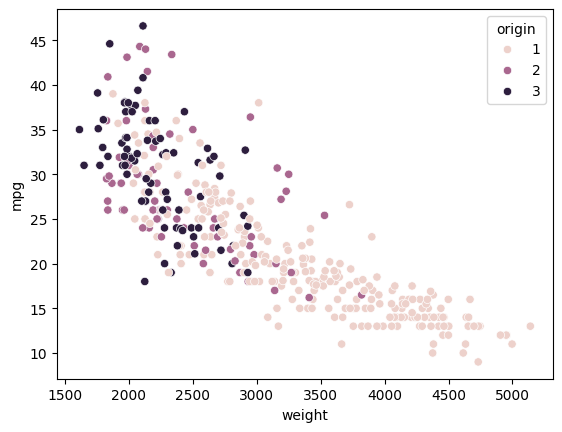

In [3]:
sns.scatterplot(x="weight", y="mpg", hue="origin", data=df)

<Axes: xlabel='cylinders', ylabel='horsepower'>

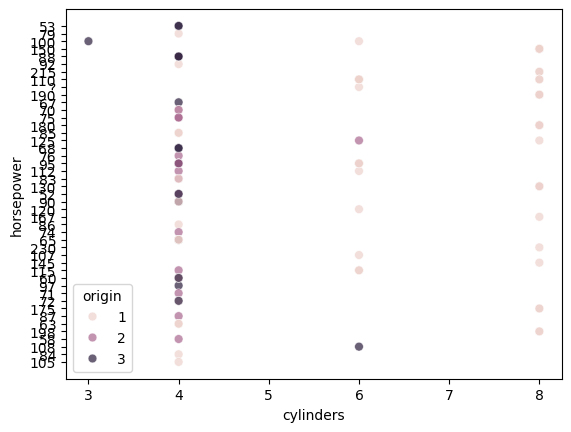

In [4]:
sampled = df.sample(frac=0.25, random_state=42)
sns.scatterplot(x="cylinders", y="horsepower", hue="origin", data=sampled, alpha=0.7, s=40)

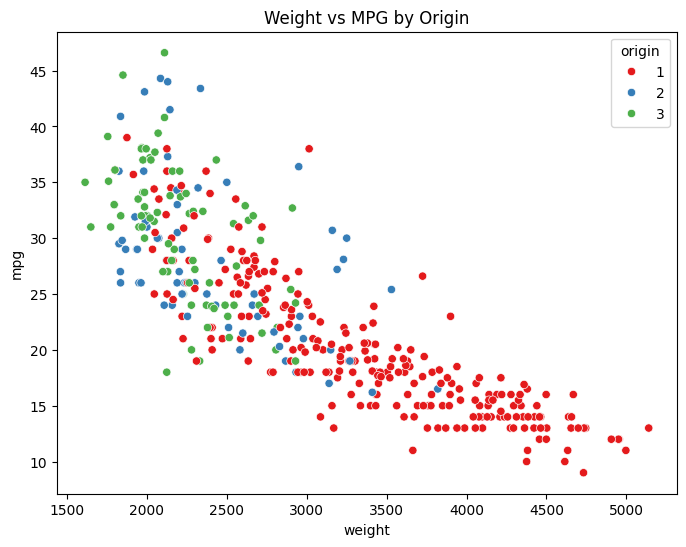

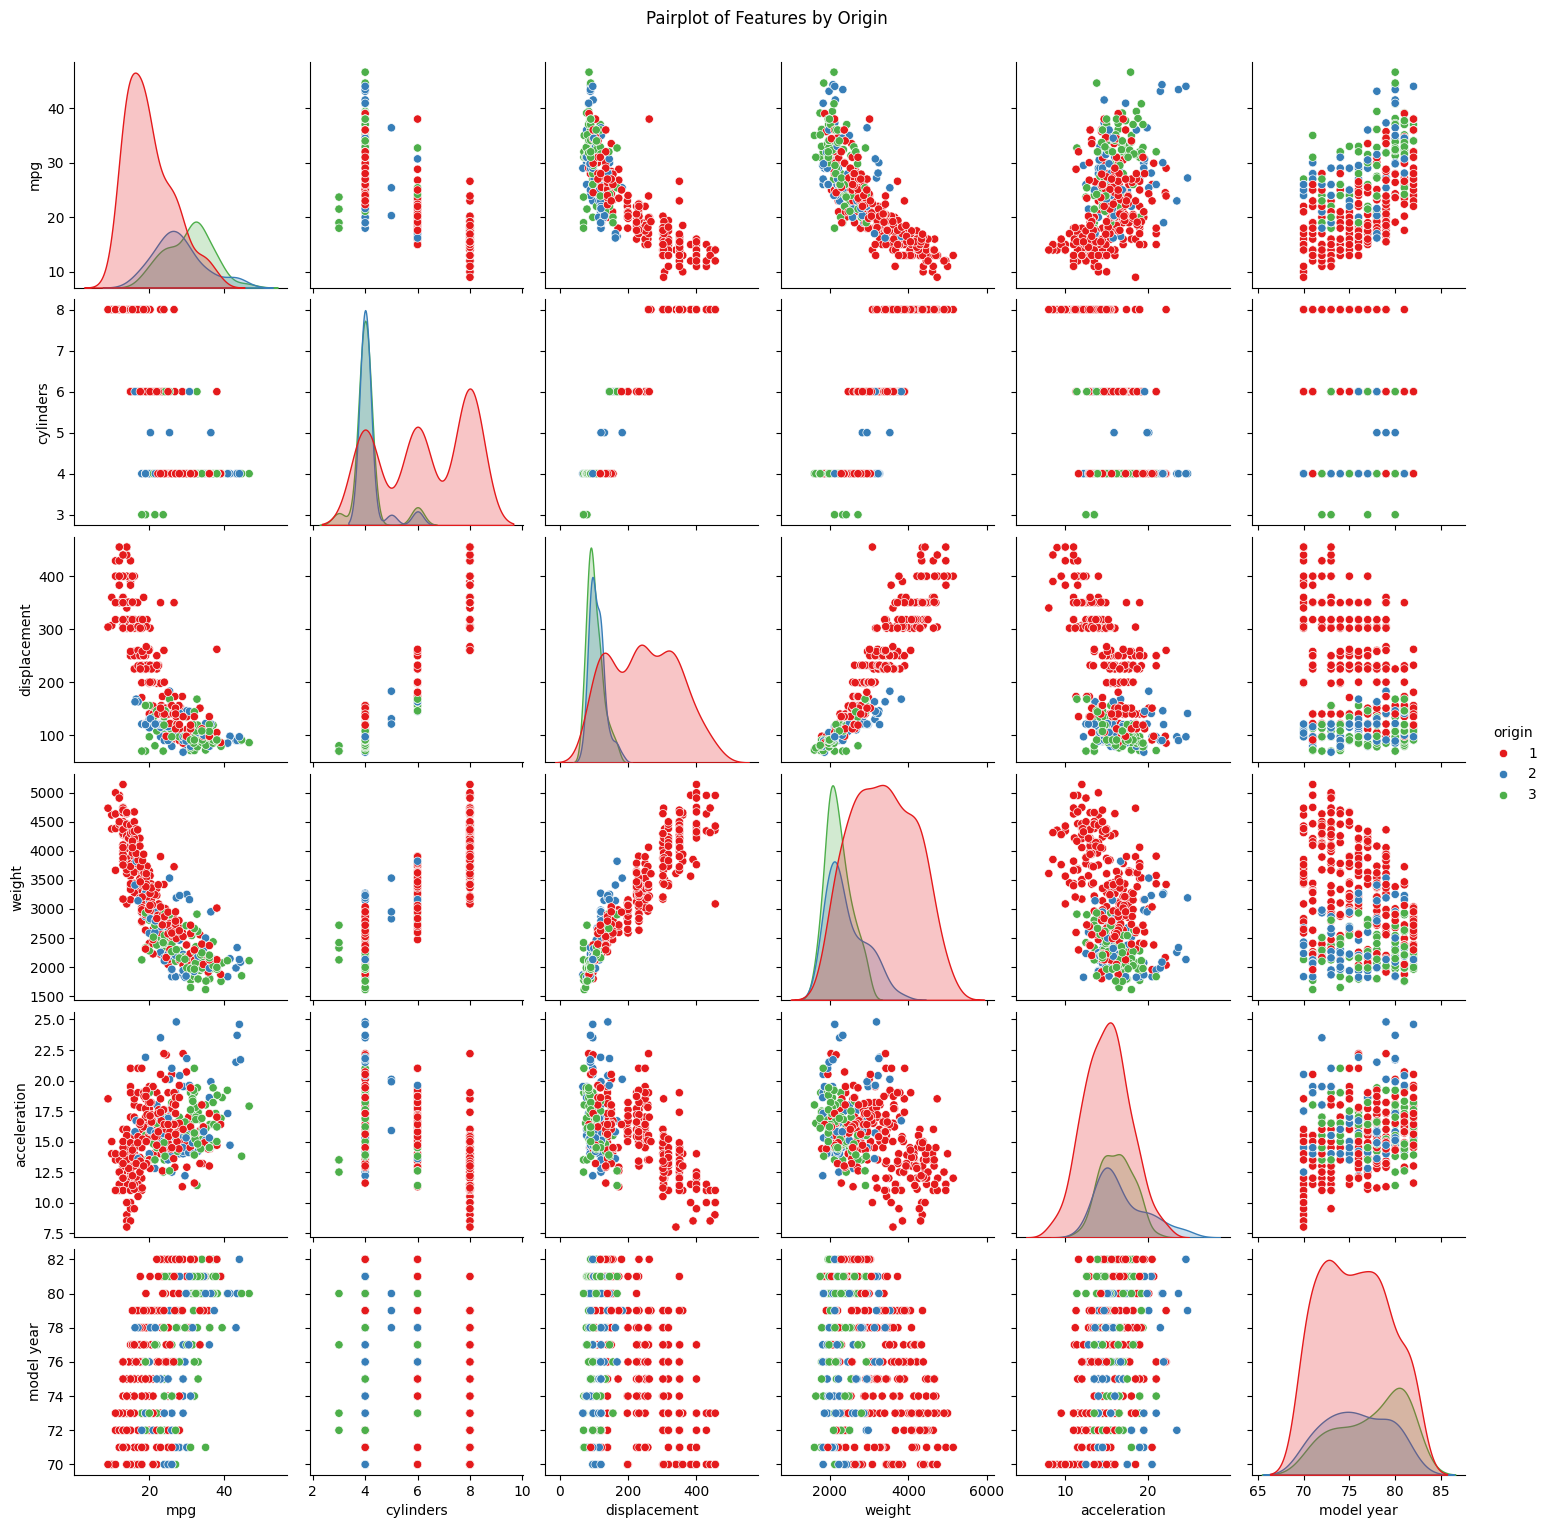

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


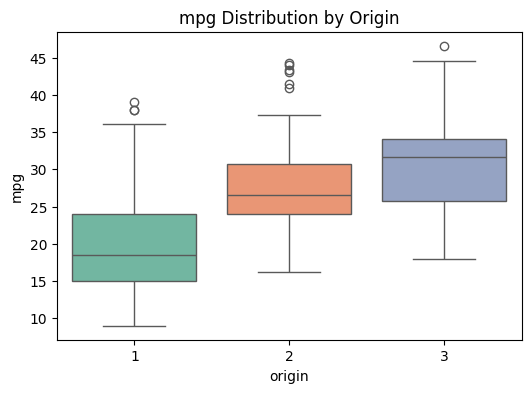

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


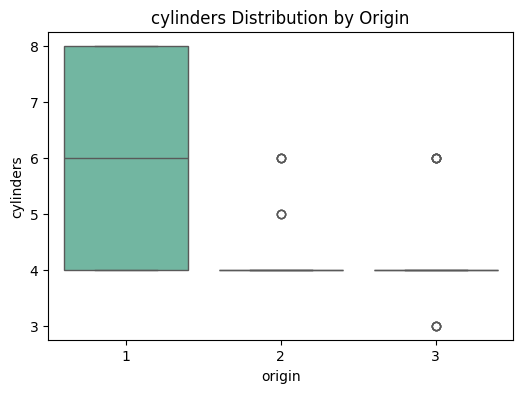

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


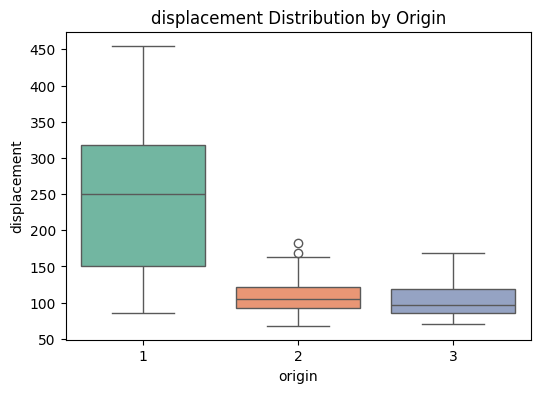

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


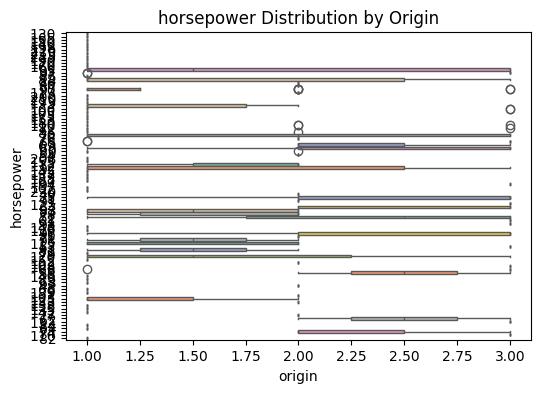

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


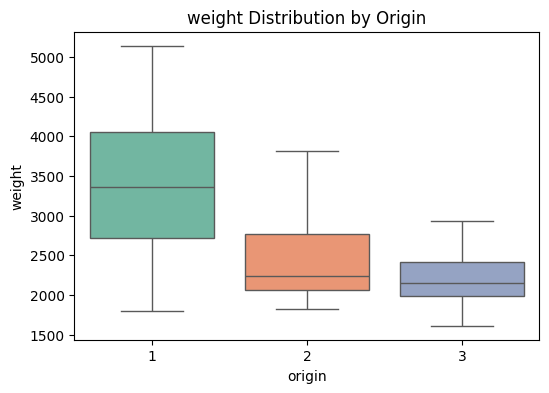

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


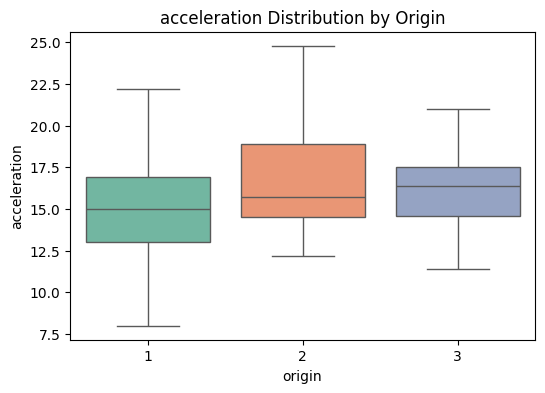

C:\Users\novij\AppData\Local\Temp\ipykernel_35824\107829789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin", y=feature, data=df, palette="Set2")


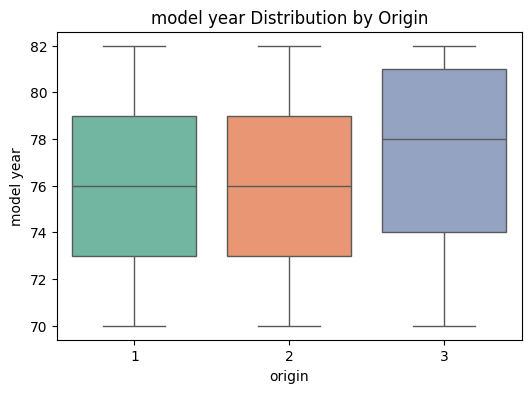

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatterplot: Weight vs MPG by origin
plt.figure(figsize=(8,6))
sns.scatterplot(x="weight", y="mpg", hue="origin", data=df, palette="Set1")
plt.title("Weight vs MPG by Origin")
plt.show()

# Pairplot of numerical features colored by origin
numeric_features = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"]
sns.pairplot(df[numeric_features + ["origin"]], hue="origin", palette="Set1", diag_kind="kde")
plt.suptitle("Pairplot of Features by Origin", y=1.02)
plt.show()

# Boxplots: compare distribution of each numeric feature across origins
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="origin", y=feature, data=df, palette="Set2")
    plt.title(f"{feature} Distribution by Origin")
    plt.show()


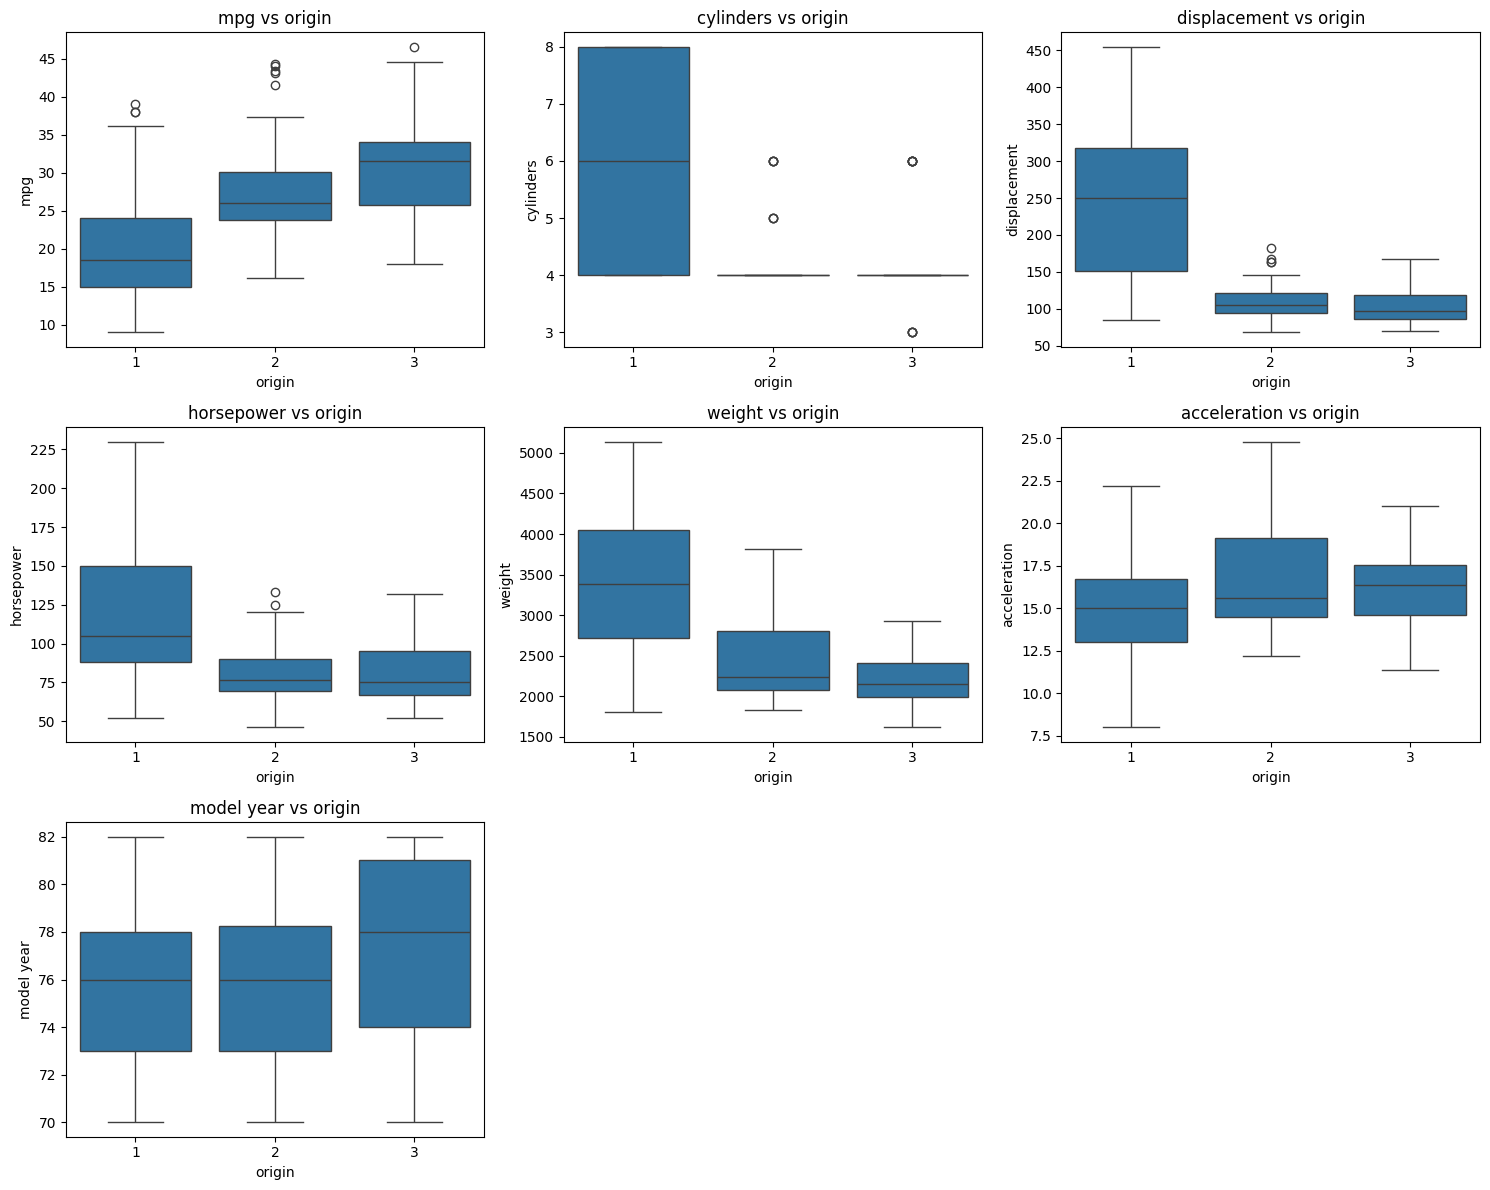

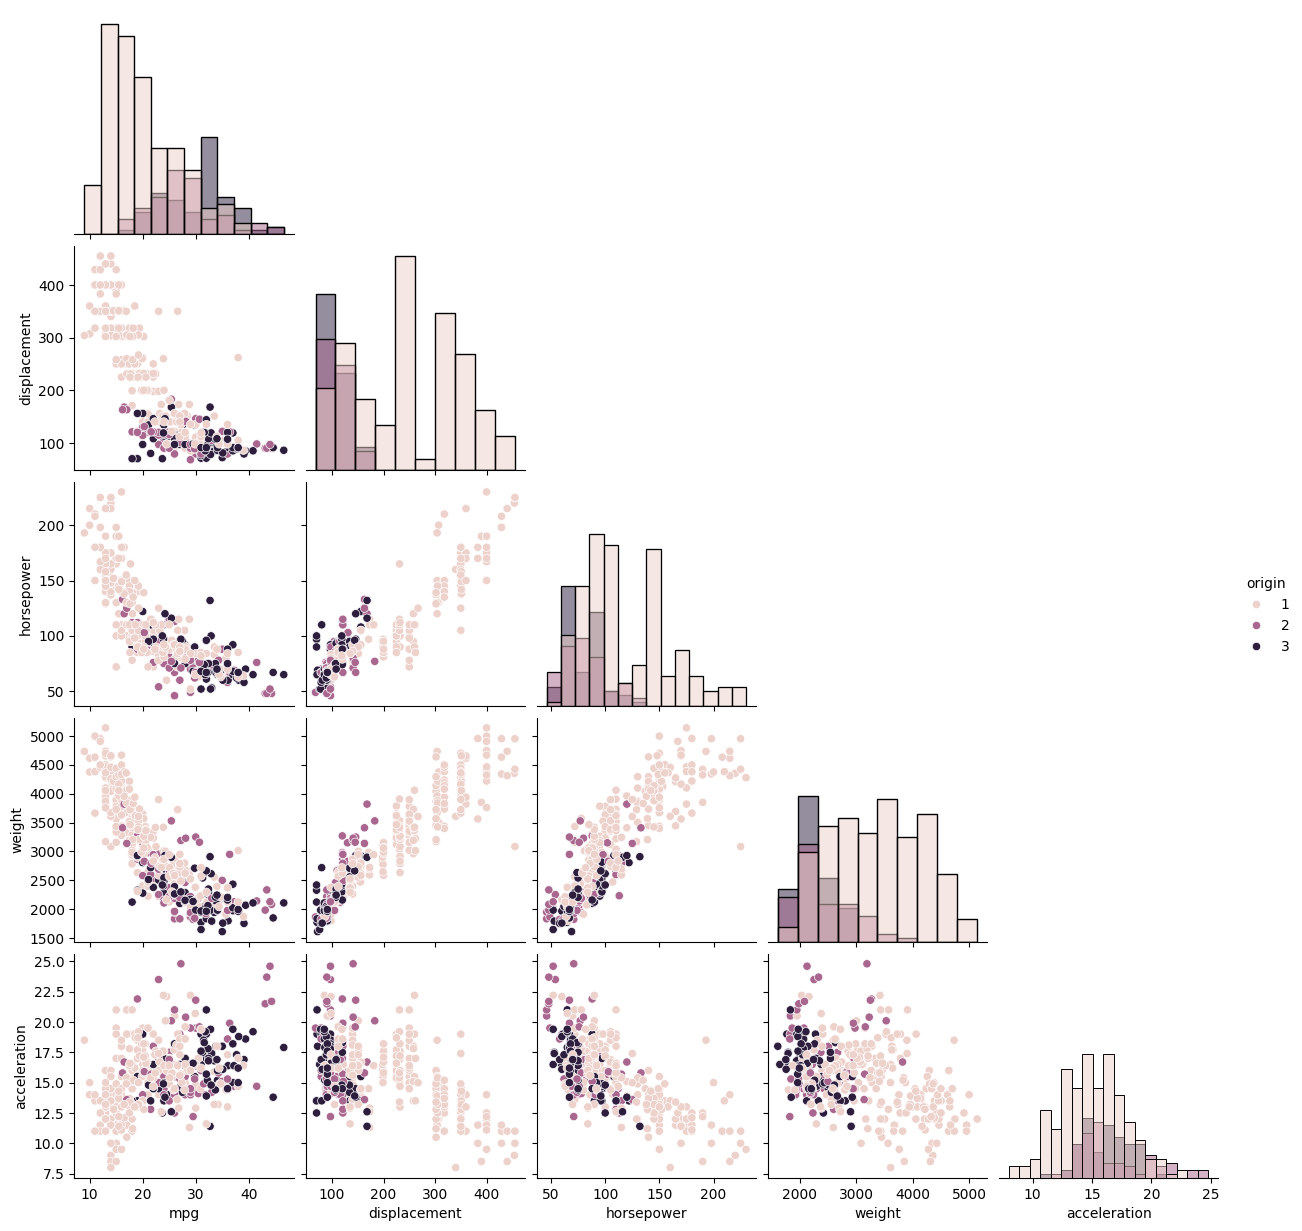

,feature,anova_f,anova_p,mutual_info
2,displacement,147.124123,2.628295e-48,0.567031
3,horsepower,61.342093,6.987301e-24,0.349035
4,weight,112.772038,2.353054e-39,0.288096
1,cylinders,115.618418,3.915191e-40,0.287708
0,mpg,96.601530,8.673818e-35,0.270953
5,acceleration,14.961844,5.494850e-07,0.126911
6,model year,8.105900,3.556578e-04,0.030622


In [6]:
from sklearn.feature_selection import f_classif, mutual_info_classif

origin_features = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"]
origin_target = "origin"

origin_df = df[origin_features + [origin_target]].copy()
for col in origin_features + [origin_target]:
    origin_df[col] = pd.to_numeric(origin_df[col], errors="coerce")
origin_df = origin_df.dropna()
origin_df[origin_target] = origin_df[origin_target].astype(int)

#Boxplots: ser om fordelinger adskiller sig mellem origin-grupper
ncols = 3
nrows = int(np.ceil(len(origin_features) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(origin_features):
    sns.boxplot(data=origin_df, x=origin_target, y=feat, ax=axes[i])
    axes[i].set_title(f"{feat} vs origin")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#Pairplot med farve paa origin for hurtig visuel separering
sns.pairplot(
    origin_df[["mpg", "displacement", "horsepower", "weight", "acceleration", origin_target]],
    hue=origin_target,
    corner=True,
    diag_kind="hist"
)
plt.show()

#Feature-ranking (hoejere = mere informativ ift. origin)
X_origin = origin_df[origin_features]
y_origin = origin_df[origin_target]

f_vals, p_vals = f_classif(X_origin, y_origin)
mi_vals = mutual_info_classif(X_origin, y_origin, random_state=42)

origin_feature_rank = pd.DataFrame({
    "feature": origin_features,
    "anova_f": f_vals,
    "anova_p": p_vals,
    "mutual_info": mi_vals
}).sort_values(["mutual_info", "anova_f"], ascending=False)

origin_feature_rank

In [7]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["horsepower"] = df.groupby("cylinders")["horsepower"]\
                     .transform(lambda x: x.fillna(x.mean()))

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# ------------------ Prepare data ------------------
# Drop non-numeric or irrelevant columns
X = df.drop(columns=["origin", "car name"])
y = df["origin"]

# One-hot encode the target
y_onehot = pd.get_dummies(y, prefix='origin')

# Handle missing values (if any)
X = X.fillna(X.median())

# Train / Validation / Test split (70/15/15) with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.idxmax(axis=1)
)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# Optional scaling for models like Logistic Regression, KNN, SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert one-hot to single integer labels for evaluation
y_train_labels = y_train.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))
y_val_labels = y_val.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))
y_test_labels = y_test.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

# ------------------ Models and hyperparameters ------------------
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

param_grids = {
    "Decision Tree": {
        "max_depth": [None, 3, 5, 7, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": [None, "balanced"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7]
    }
}

# ------------------ Evaluation function ------------------
def evaluate_model(model, X, y, label="Test"):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    
    # Specificity / fallout calculations for binary classification
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fallout = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    else:
        specificity = fallout = np.nan
    
    print(f"\n----- {label} Evaluation -----")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y, y_pred, zero_division=0))
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall: {recall_score(y, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(y, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Specificity (approx.): {specificity:.4f}")
    print(f"Fallout (approx.): {fallout:.4f}")

# ------------------ Train, tune, and evaluate ------------------
best_models = {}
for name, model in models.items():
    print(f"\n===== Model: {name} =====")
    
    # Scale input for certain models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_tr, X_vl, X_te = X_train_scaled, X_val_scaled, X_test_scaled
    else:
        X_tr, X_vl, X_te = X_train, X_val, X_test
    
    # RandomizedSearchCV for hyperparameter tuning
    grid = param_grids.get(name)
    if grid:
        rs = RandomizedSearchCV(model, grid, n_iter=10, cv=3, scoring="accuracy", random_state=42, n_jobs=-1)
        rs.fit(X_tr, y_train_labels)  # Use single-label for fitting
        best_model = rs.best_estimator_
        print("Best Hyperparameters:", rs.best_params_)
    else:
        best_model = model
        best_model.fit(X_tr, y_train_labels)
    
    # Save for later comparison
    best_models[name] = best_model
    
    # Evaluate on Train, Validation, Test
    print(f"\n===== Model: {name} =====")
    evaluate_model(best_model, X_tr, y_train_labels, "Train")
    print(f"\n===== Model: {name} =====")
    evaluate_model(best_model, X_vl, y_val_labels, "Validation")
    print(f"\n===== Model: {name} =====")
    evaluate_model(best_model, X_te, y_test_labels, "Test")


===== Model: Decision Tree =====
Best Hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}

===== Model: Decision Tree =====

----- Train Evaluation -----
Confusion Matrix:
 [[174   0   0]
 [  0  49   0]
 [  0   0  55]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       174
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        55

    accuracy                           1.00       278
   macro avg       1.00      1.00      1.00       278
weighted avg       1.00      1.00      1.00       278

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Specificity (approx.): nan
Fallout (approx.): nan

===== Model: Decision Tree =====

----- Validation Evaluation -----
Confusion Matrix:
 [[34  3  0]
 [ 2  6  3]
 [ 0  3  9]]
              precision    recall  f1-score   support

           1       0.94      0.92      0.93     

In [11]:
best_models

{'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=15,
                        min_samples_leaf=2, min_samples_split=5, n_estimators=50,
                        random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                            random_state=42)}

In [12]:
best_models["Random Forest"]

,n_estimators,50
,criterion,'gini'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
import joblib

joblib.dump(best_models['Random Forest'], "classification_model.pkl")